In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load dataset

In [ ]:
df = pd.read_csv("Sales.csv")

# Basic info
print(df.shape)
print(df.head(10))
print(df.info())
print(df.describe())

(9800, 18)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
5       6  CA-2015-115812  09/06/2015  14/06/2015  Standard Class    BH-11710   
6       7  CA-2015-115812  09/06/2015  14/06/2015  Standard Class    BH-11710   
7       8  CA-2015-115812  09/06/2015  14/06/2015  Standard Class    BH-11710   
8       9  CA-2015-115812  09/06/2015  14/06/2015  Standard Class    BH-11710   
9      10  CA-2015-115812  09/06/2015  14/06/2015  Standard Class    BH-11710   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute  

## Convert to Date and Postal code

In [48]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format="%d/%m/%Y")
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format="%d/%m/%Y")
df['Postal Code'] = df['Postal Code'].fillna(0).astype(int)

In [49]:
# Missing values
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


In [50]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Order Day'] = df['Order Date'].dt.day
df['Order Weekday'] = df['Order Date'].dt.weekday
df['Month Name'] = df['Order Date'].dt.strftime('%B')
df['Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)

df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

## Bivariate Analysis

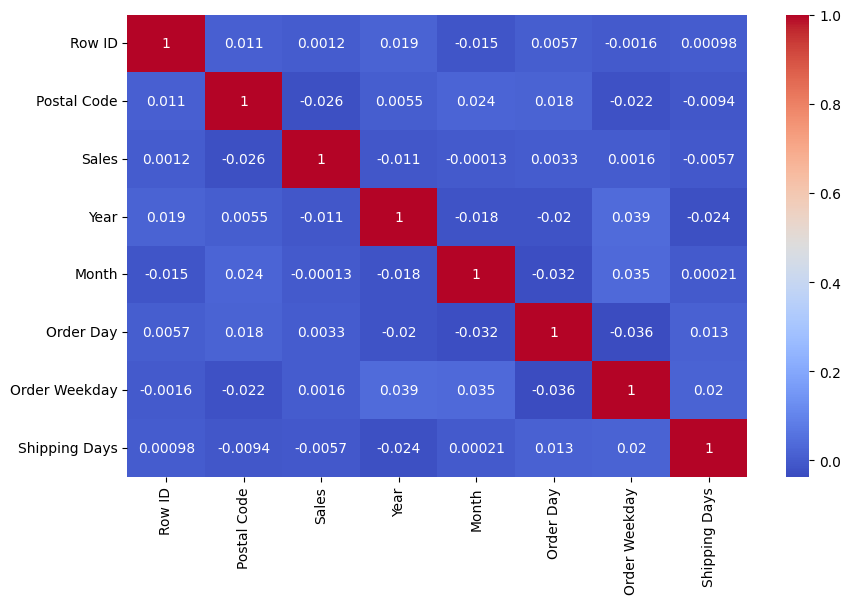

In [51]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

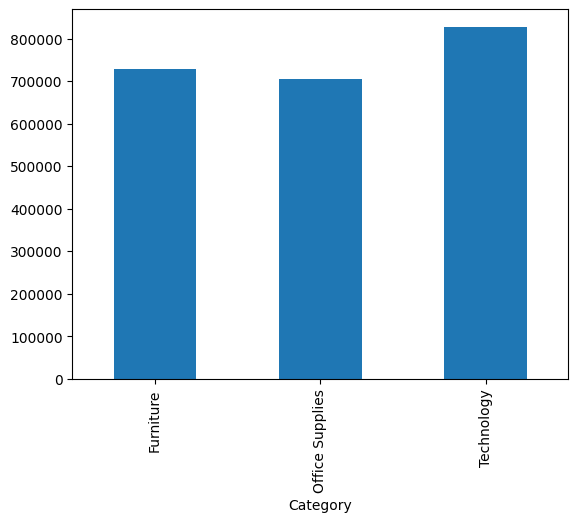

In [52]:
# Category-wise profit
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.show()

In [53]:
# Groupby analysis

print("\n" + "="*40)
print("📊 SALES BY REGION")
print("="*40)
print(df.groupby('Region')['Sales'].sum().to_string())

print("\n" + "="*40)
print("📊 AVERAGE SALES BY CATEGORY")
print("="*40)
print(df.groupby('Category')['Sales'].mean().to_string())

# Top products (if column exists)
if 'Product Name' in df.columns:
    print("\n" + "="*40)
    print("🏆 TOP 10 PRODUCTS BY SALES")
    print("="*40)

    top_products = df.groupby('Product Name')['Sales'].sum() \
                     .sort_values(ascending=False) \
                     .head(10)

    print(top_products.to_string())


📊 SALES BY REGION
Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845

📊 AVERAGE SALES BY CATEGORY
Category
Furniture          350.653790
Office Supplies    119.381001
Technology         456.401474

🏆 TOP 10 PRODUCTS BY SALES
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
G

In [ ]:
df.to_csv("superstore_sales.csv", index=False)

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

df = df.drop(columns=[
    'Row ID', 'Order ID', 'Customer Name',
    'Product Name', 'Order Date', 'Ship Date'
])

df = pd.get_dummies(df, drop_first=True)

target = 'Shipping Days'

X = df.drop(columns=[target])
y = df[target]

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print("Random Forest MAE:", mae)

Random Forest MAE: 0.7546490025484379
